### **Maestría en Inteligencia Artificial Aplicada**

###**Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

### **Actividad de la Semana: Problema de Clasificación con Datos Desbalanceados : Oil-Spill**

Alumno: Jareth Israel Rivera Pineda

Matrícula: A01411621

# **Introducción**

* La actividad se basa en los datos conocidos como "oil-spill" (derrame de petróleo).

* En la web puedes encontrar varias referencias a este mismo problema, pero en donde el archivo de datos no es exactamente igual. Por ello y para asegurar que el conjunto de datos con el que estaremos trabajando es el mismo para todos, dicho archivo lo encontrarás en Canvas.

* El archivo con los datos de esta actividad lo encuentras en Canvas con el nombre "oil-spill.csv".

En la siguiente liga se encuentra el artículo original relacionado a dicha base de datos. Los datos incluyen 50 columnas y 937 registros. Las primeras 49 columnas son métricas obtenidas de imágenes satelitales del océano, en algunas de las cuales se tiene petróleo que fue derramado por alguna fuente desconocida. En el artículo se describe a detalle la manera en que se obtuvieron dichas columnas. Para la actividad es suficiente considerarlas como de valor numérico, donde cada valor es una medida de información en la imagen. La última columna llamada "target" es de valor 1 (hay derrame en ese pedazo de la imagen) o 0 (no hay derrame en ese pedazo de la imagen).

https://webdocs.cs.ualberta.ca/~holte/Publications/oilspill.pdf

Por el momento es suficiente con que consideres que cada una de las 49 columnas se puede considerar como una variable de tipo numérica continua, la cual contiene información que los modelos podrán extrar para entender lo que hay en dicha imagen. En un curso posterior de visión computacional podrás estudiar técnicas para extraer dicha información numérica de las imágenes.

En la siguiente liga puedes encontrar información de varias de las métricas de scikit-learn que estaremos utilizando:

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

La librería de scikit-learn no incluye la media geométrica **G_mean**, pero sabemos que se puede obtener con la fórmula $G_{mean}=\sqrt{\frac{VP*VN}{(VP+FN) * (VN+FP)}}$, usando los verdaderos y falsos, positivos y negativos.

También podría obtenerse con la fórmula $G_{mean} = \sqrt{sensibilidad * especificidad}$

Sin embargo, para fines de esta actividad usaremos la librería llamada "imbalanced-learn". Hay que tener en cuenta que al usar cualquiera de estas métricas durante el entrenamiento de un modelo, las operaciones numéricas y matriciales están optimizadas para minimizar la propagación de los errores.

Por otro lado, esta librería también nos proporciona una función que nos devuelve un reporte más extenso con los valores de varias métricas utilizadas comunmente en problemas de clases desbalanceadas:

https://glemaitre.github.io/imbalanced-learn/generated/imblearn.metrics.geometric_mean_score.html

# **Ejercicio-1**

### **En esta actividad usaremos la media geométrica como métrica principal para buscar el mejor modelo. Responde a los siguientes incisos:**

* ### **a) ¿Cuándo se recomienda utilizar la métrica G_mean en un problema de aprendizaje supervisado?**

* ### **b) ¿Cuál es la diferencia, pros y contras, de la G_mean con la f1_score?**

* ### **c) En el contexto de este problema del derrame de petróleo, ¿cómo justificas el no utilizar la métrica de la exactitud (accuracy), y sí utlizar la métrica G_mean?**

* ### **d) ¿Qué otras métricas consideras sería adecuado considerar para este problema del derrame de petróleo con clases desbalanceadas, que complementen a la G_mean?**





### +++++++++++ Inicia sección para agregar texto ++++++++++++++++

* 1a) La métrica G_mean se recomienda en problemas de clasificación con clases desbalanceadas, ya que evalúa el desempeño del modelo considerando tanto la sensibilidad como la especificidad, evitando que el modelo se beneficie de predecir solo la clase mayoritaria.

* 1b) La principal diferencia es que G_mean mide el equilibrio entre la capacidad del modelo para identificar correctamente ambas clases (sensibilidad y especificidad), mientras que f1_score se enfoca únicamente en la clase positiva, combinando precisión y recall.

G_mean - **Pros:** Evalúa el desempeño global del modelo en ambas clases, penaliza modelos que ignoran la clase minoritaria o la mayoritaria y es muy adecuada para problemas fuertemente desbalanceados. **Contras:** No distingue explícitamente entre tipos de error (falsos positivos vs falsos negativos).

f1_score - **Pros:** Útil cuando la clase positiva es la más relevante y balancea precisión y recall de esa clase. **Contras:** No considera el desempeño sobre la clase negativa y puede dar una impresión optimista si la clase mayoritaria se clasifica mal.

* 1c) Debido al fuerte desbalance entre “derrame” y “no derrame”, un modelo puede tener alta accuracy sin detectar derrames reales. G_mean es más adecuada porque exige buen desempeño tanto al detectar derrames como al identificar correctamente zonas sin derrame.

* 1d) Además de G_mean, sería conveniente considerar las siguientes métricas:

**Recall (sensibilidad) de la clase positiva**: para asegurar que los derrames reales sean detectados.

**Precision**: para controlar la cantidad de falsas alarmas.

**F1-score**: como complemento centrado en la clase positiva.

**ROC-AUC**: para evaluar la capacidad discriminativa del modelo de forma independiente del umbral.

**Matriz de confusión**: para analizar explícitamente el tipo de errores que comete el modelo.

Estas métricas, en conjunto con G_mean, proporcionan una visión más completa y robusta del desempeño del modelo en un problema de clasificación con clases desbalanceadas.



### +++++++++++ Termina sección para agregar texto ++++++++++++++

In [35]:
# Incluye todas librerías que consideres necesarias:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* **Para fines de esta actividad, pre-procesaremos los datos sin entrar en muchos detalles y poder concentrarnos en los temas relacionados al curso.**

* **Siempre podrás regresar en el futuro y trabajar de mejor manera el pre-procesamiento de los datos.**

In [36]:
# Cargamos los datos del archivo:
path ='/content/drive/MyDrive/MNA/TC4058.10/oil_spill (1).csv'
df = pd.read_csv(path)

# Eliminamos las siguientes columnas:
df.drop("f_1", axis=1, inplace=True)    # Esta columna contiene información de secciones (batches) de las imágenes que no requerimos para esta actividad.
df.drop("f_23", axis=1, inplace=True)   # Esta columna tiene un solo valor constante.


print('Dimensión del DataFrame',df.shape)
df.head(4).T


Dimensión del DataFrame (937, 48)


,0,1,2,3
f_2,2558.00,22325.00,115.00,1201.00
f_3,1506.09,79.11,1449.85,1562.53
f_4,456.63,841.03,608.43,295.65
f_5,90.00,180.00,88.00,66.00
f_6,6395000.00,55812500.00,287500.00,3002500.00
f_7,40.88,51.11,40.42,42.40
f_8,7.89,1.21,7.34,7.97
f_9,29780.00,61900.00,3340.00,18030.00
f_10,0.19,0.02,0.18,0.19
f_11,214.70,901.70,86.10,166.50


In [37]:
# Particionamos los datos de entrada (X) y de salida (y):
X,y = df.iloc[:,:-1], df.iloc[:,-1]

# Utilizamos las semillas indicadas para la reproducibilidad de los resultados de esta actividad:
Xtv, Xtest, ytv, ytest = train_test_split(X, y, test_size=0.12, stratify=y, shuffle=True, random_state=1)
Xtrain, Xval, ytrain, yval = train_test_split(Xtv, ytv, test_size=0.2, shuffle=True, random_state=7)


# Veamos la partición de los tres conjuntos.
# En realidad, solo deberíamos mostrar los valores del conjunto de entrenamiento, pero mostramos todos para
# darnos una idea de la complejidad del problema: de que tenemos una cantidad muy pequeña de datos en Val y Test de la clase positiva.

print('\nPartición:')
tmp = 100 * (ytrain.sum() / len(ytrain))
print('Train:')
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (ytrain.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(ytrain)-ytrain.sum()), 100-tmp))

print('\nValidation:')
tmp = 100 * (yval.sum() / len(yval))
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (yval.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(yval)-yval.sum()), 100-tmp))

print('\nTest:')
tmp = 100 * (ytest.sum() / len(ytest))
print('Conteo_clase_positiva=%d, Porcentaje_clase_positiva=%.2f%%' % (ytest.sum(), tmp))
print('Conteo_clase_negativa=%d, Porcentaje_clase_negativa=%.2f%%' % ((len(ytest)-ytest.sum()), 100-tmp))


Partición:
Train:
Conteo_clase_positiva=28, Porcentaje_clase_positiva=4.25%
Conteo_clase_negativa=631, Porcentaje_clase_negativa=95.75%

Validation:
Conteo_clase_positiva=8, Porcentaje_clase_positiva=4.85%
Conteo_clase_negativa=157, Porcentaje_clase_negativa=95.15%

Test:
Conteo_clase_positiva=5, Porcentaje_clase_positiva=4.42%
Conteo_clase_negativa=108, Porcentaje_clase_negativa=95.58%


**Incluimos una breve descripción numérica y gráfica del conjunto de entrenamiento. Es lo mínimo, para una primera aproximación. Más adelante puedes regresar a mejorar el pre-preocesamiento.**

**Puedes incluir más celdas con análisis adicionales, si así lo deseas.**

In [38]:
Xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
f_2,659.0,350.377845,1.911459e+03,10.00,19.000,63.00,134.000,28526.00
f_3,659.0,692.040516,6.013521e+02,1.92,83.905,646.26,1229.325,1789.13
f_4,659.0,853.822398,5.259526e+02,1.00,435.500,719.81,1238.040,2724.57
f_5,659.0,85.613050,4.564260e+01,0.00,54.000,74.00,120.500,180.00
f_6,659.0,831366.966616,4.158159e+06,71718.00,125000.000,185000.00,337500.000,71315000.00
f_7,659.0,43.517132,1.287405e+01,21.24,33.760,40.35,53.090,82.64
f_8,659.0,9.244294,3.590490e+00,1.21,6.935,8.33,11.045,23.47
f_9,659.0,4094.624431,8.960913e+03,704.00,1332.000,2100.00,3445.000,160740.00
f_10,659.0,0.221730,8.687786e-02,0.02,0.170,0.21,0.260,0.67
f_11,659.0,110.794537,6.187135e+01,41.00,84.400,100.10,116.300,901.70


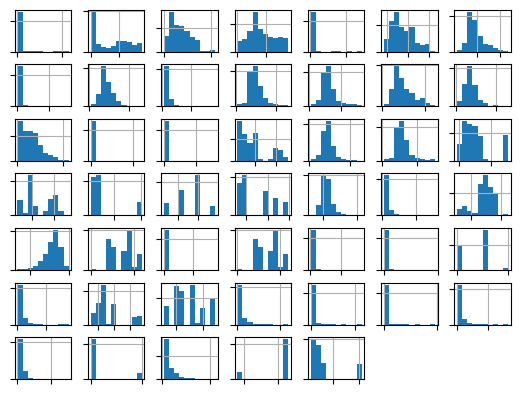

In [39]:
ax = Xtrain.hist()  # Histogramas:
# Quitemos toda la información del gráfico para visualizarlo de manera sencilla:
for axis in ax.flatten():
  axis.set_title('')
  axis.set_xticklabels([])
  axis.set_yticklabels([])
plt.show()



In [40]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 659 entries, 433 to 625
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f_2     659 non-null    int64  
 1   f_3     659 non-null    float64
 2   f_4     659 non-null    float64
 3   f_5     659 non-null    int64  
 4   f_6     659 non-null    float64
 5   f_7     659 non-null    float64
 6   f_8     659 non-null    float64
 7   f_9     659 non-null    float64
 8   f_10    659 non-null    float64
 9   f_11    659 non-null    float64
 10  f_12    659 non-null    float64
 11  f_13    659 non-null    float64
 12  f_14    659 non-null    float64
 13  f_15    659 non-null    float64
 14  f_16    659 non-null    float64
 15  f_17    659 non-null    float64
 16  f_18    659 non-null    float64
 17  f_19    659 non-null    float64
 18  f_20    659 non-null    float64
 19  f_21    659 non-null    float64
 20  f_22    659 non-null    float64
 21  f_24    659 non-null    float64
 22  f_25 

**En resumen:**

* De lo anterior observamos que:
  * Todos los valores ya son numéricos, positivos, negativos o cero.
  * No hay datos perdidios.
  * La diferencia de escala entre todos los factores es muy diversa y la distribución de las variables también es muy variada.

* **Como una primera aproximación transformaremos todos los factores con la Yeo-Johnson para corregir un poco el sesgo de las distribuciones que suele afectar en general a los modelos como la regresión logística y luego los escalaremos para ayudar a que todos los factores estén en iguales condiciones de mostrar su importancia.**

# **Ejercicio-2**

### **En relación a la transformación Yeo-Johnson, investiga:**

* ### **a) ¿En qué consiste dicha transformación?**

* ### **b) ¿Cuál es su diferencia con la transformación Box-Cox?**


### +++++++++++ Inicia sección para agregar texto ++++++++++++++++

* 2a) La transformación Yeo-Johnson es una técnica de transformación de variables que busca aproximar los datos a una distribución normal y reducir la asimetría. Se aplica de forma automática mediante un parámetro λ, y tiene la ventaja de que puede utilizarse con valores positivos, cero y negativos, lo que la hace muy flexible en problemas reales.

* 2b) La principal diferencia es que la transformación Box-Cox solo puede aplicarse a datos estrictamente positivos, mientras que Yeo-Johnson puede aplicarse a datos positivos y negativos.

**Box-Cox**: Requiere valores > 0 y es menos flexible en datos reales

**Yeo-Johnson**: Acepta valores negativos y cero y es más general y práctica

Por esta razón, Yeo-Johnson suele preferirse cuando no se puede garantizar que todas las variables sean positivas.



### +++++++++++ Termina sección para agregar texto ++++++++++++++

In [41]:
# Transformaciones numéricas evitando el filtrado de información:

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import make_scorer
from imblearn.metrics import geometric_mean_score

numericas_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='mean')),
                                       ('yeo-johnson', PowerTransformer(method='yeo-johnson')),
                                       ('std_transformer', StandardScaler()),
                                       ])

numericas_pipeline_nombres = Xtrain.columns

columnasTransformer = ColumnTransformer(transformers = [('num', numericas_pipeline, numericas_pipeline_nombres)],
                                        remainder='passthrough')

In [42]:
# Definamos la siguiente variable con la métrica G-mean a utilizar en los modelos:

mi_metrica = make_scorer(geometric_mean_score)

# **Ejercicio-3**

* ### **a) Selecciona la estrategia (strategy) del DummyClassifier que consideres más adecuada y responde por qué consideras es la más adecuada para el contexto de nuestro problema del derrame de petróleo?**

* ### **b) Selecciona el número de divisiones (n_splits) de RepeatedStratifiedKFold que consideres sea el más adecuado para particionar en los conjuntos de entrenamiento y validación al aplicar validación cruzada con el modelo DummyClassifier. Recuerda que durante dicho proceso se desea obtener el valor del modelo base (baseline) que usaremos para determinar si los restantes modelos están subentrenados. Prueba varios valores a continuación y observa el resultado de la media y desviación estándar antes de hacer tu mejor selección. Responde a continuación cómo llegaste a decidirte por valor que seleccionaste.**

* ### **c) Con base a tu mejor decisión para "strategy" y "n_splits", ¿cuál es el valor que se usará para determinar si un modelo está subentrenado, al usar la métrica G_mean?**

* ### **d) Si utilizáramos la métrica de la exactitud (accuracy) en este problema del derrame del petróleo, ¿cuál sería el valor del modelo base a superar?** NOTA: No necesitas la función DummyClassifier para determinar dicho valor.

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++


* 3a) La estrategia más adecuada es strategy="most_frequent", ya que siempre predice la clase mayoritaria (“no hay derrame”).
Esto es coherente con el objetivo del modelo base (baseline): representar el peor escenario razonable en un problema con clases desbalanceadas y servir como referencia mínima que los modelos reales deben superar.

* 3b) Un valor adecuado es n_splits = 5.
Al probar distintos valores (por ejemplo 3, 5 y 10), se observa que: Con pocos splits, la estimación es menos estable y que con muchos splits, la varianza aumenta debido al muy bajo número de ejemplos positivos. Con 5 divisiones se logra un buen balance entre estabilidad de la media y varianza razonable, lo cual es apropiado para estimar un baseline confiable.

* 3c) Con strategy="most_frequent", el modelo no detecta ningún derrame, por lo que cualquier modelo con G_mean > 0 no está subentrenado y supera al baseline.

* 3d) Si siempre se predice la clase mayoritaria, la accuracy será aproximadamente igual al porcentaje de la clase negativa en el dataset, que ronda el 95%–96%. Esto demuestra por qué accuracy es engañosa en este problema: un modelo inútil puede tener una accuracy muy alta sin detectar derrames reales.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

NOTA: Recuerda revisar la documentación correspondiente de sklearn para la selección adecuada de los argumentos:

* DummyClassifier:

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

* RepeatedStratifiedKFold:

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html

In [43]:
# Utilicemos la función DummyClassifier de sklearn con la métrica G-mean para
# obtener el desempeño del modelo base (baseline).

# Usa esta celda para probar diferentes valores de "strategy" y "n_splits".
# Con base a los resultados observados selecciona tus mejores opciones y
# responde a las preguntas de los incisos anteriores del Ejercicio-3.

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from numpy import mean, std


# ----------------- Incluye a continuación tus mejores opciones -----------

mi_estrategia = "most_frequent"

mi_nsplits = 5


# ----------------- Fin para realizar ajustes -----------------------------



# No modifiques las semillas.
cv = RepeatedStratifiedKFold(n_splits=mi_nsplits, n_repeats=3, random_state=7)  # Validación Cruzada Estratificada.
modeloD = DummyClassifier(strategy=mi_estrategia, random_state=7)
pipelineD = Pipeline(steps=[('ct',columnasTransformer),('Dummy',modeloD)])
scores = cross_val_score(pipelineD, Xtrain, ytrain, scoring=mi_metrica, cv=cv, n_jobs=-1)  # Cuidamos el filtrado de información.

print('Veamos los desempeños obtenidos con la DummyClassifier y la métrica G-mean.')
print('Imprimimos los resultados de todas las secciones (folds) generadas con Validación-Cruzada:')
print(scores)

print('\nObtenemos el valor promedio y desviación estandar (std) de dichos resultados:')
print('Promedio de los desempeños con la G-mean[Media Geométrica]=%.3f, std=(%.3f)' % (mean(scores), std(scores)))


Veamos los desempeños obtenidos con la DummyClassifier y la métrica G-mean.
Imprimimos los resultados de todas las secciones (folds) generadas con Validación-Cruzada:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Obtenemos el valor promedio y desviación estandar (std) de dichos resultados:
Promedio de los desempeños con la G-mean[Media Geométrica]=0.000, std=(0.000)


* ### **Ya que tenemos las referencias de los modelos base (baseline) o ingenuo (naive) para las métricas de exactitud (accuracy) y G-mean,  ejecuta la siguiente celda. Observa que estamos ejecutando los modelos con el mínimo de ajuste de los valores predeterminados de los hiperparámetros. Esto con el objetivo de tener un punto de partida sobre qué tan alejados estamos de obtener buenos modelos. Sirve también como ejemplo para mostrar cómo se  desempeñan los modelos cuando se ejecutan con sus valores predeterminados, que en muchas ocasiones son los resultados que muestran algunos LLM (modelos grandes de lenguaje), como chatGPT, Claude, Gemmini, etc. Esto nos muestra que no porque no tengamos errores de ejecución o compilación, no significa que ya alcanzamos el objetivo buscado.**

* ### **Observa que estamos usando los conjuntos Xtv y ytv para entrenar los modelos ya que estamos utilizando validación cruzada y además, mostramos al inicio que tenemos muy pocos datos de la clase positiva minoritaria en el conjunto de validación.**

Resultados de Validación:
LR
Exactitud: >> 0.947 (0.015)
G-mean: >> 0.654 (0.119)

LASSO
Exactitud: >> 0.960 (0.009)
G-mean: >> 0.501 (0.158)

RIDGE
Exactitud: >> 0.959 (0.008)
G-mean: >> 0.541 (0.113)

EN
Exactitud: >> 0.960 (0.007)
G-mean: >> 0.540 (0.109)

kNN
Exactitud: >> 0.956 (0.006)
G-mean: >> 0.174 (0.187)



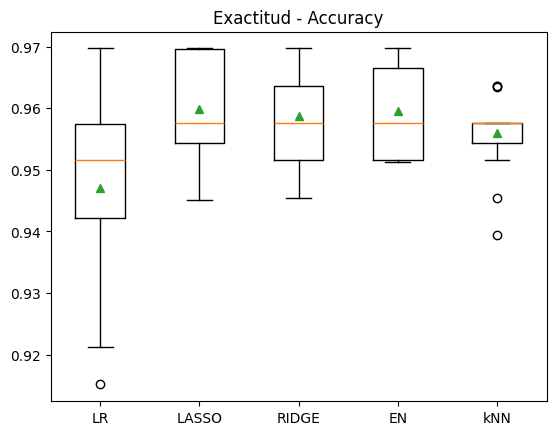

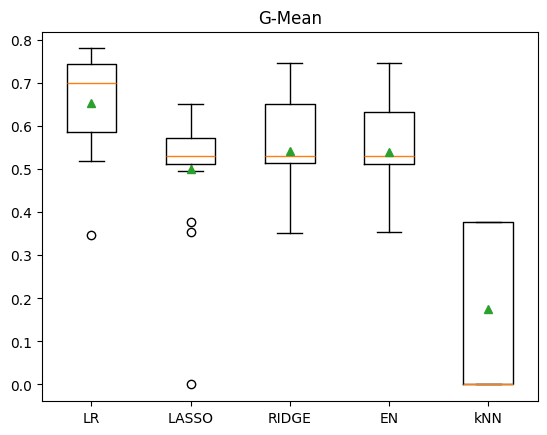

In [44]:
# Código-1:

# Ejecuta esta celda sin modificaciones.

# Estamos ejecutando los modelos con el mínimo de ajustes para usar sus valores predetermiandos
# y mostrando los desempeños con las métricas de exactitud (accuracy) y G-mean.                   # tarda unos 30 segs

# Definimos primeramente los modelos a entrenar y evaluar:

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
import matplotlib.pyplot as plt

def mis_modelos1():
  modelos, nombres = list(), list()

  modelos.append(LogisticRegression(penalty=None, # Este valor del argumento define el modelo sin regularización.
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LR')


  modelos.append(LogisticRegression(penalty='l1',  # modelo Lasso o de métrica L1.
                                    solver='liblinear',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LASSO')


  modelos.append(LogisticRegression(penalty='l2',   # modelo Ridge o de métrica L2.
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('RIDGE')

  modelos.append(LogisticRegression(penalty='elasticnet',  # modelo Elastic-Net o de métrica L1-L2.
                                    l1_ratio=0.5,
                                    solver='saga',
                                    max_iter=5000,
                                    random_state=1))
  nombres.append('EN')

  modelos.append(KNeighborsClassifier(n_neighbors=5))
  nombres.append('kNN')

  return modelos, nombres

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++


modelos, nombres = mis_modelos1()
resultados1, resultados2 = list(), list()
print('Resultados de Validación:')

for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
  scores = cross_validate(pipeline,
                          Xtv,
                          np.ravel(ytv),
                          scoring={'exactitud':'accuracy', 'm_geo':mi_metrica},
                          cv=cv1)

  resultados1.append(scores['test_exactitud'])
  resultados2.append(scores['test_m_geo'])

  print(nombres[i])
  print('Exactitud: >> %.3f (%.3f)' % (np.nanmean(scores['test_exactitud']), np.nanstd(scores['test_exactitud'])))
  print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
  print()

plt.boxplot(resultados1, tick_labels=nombres,  showmeans=True)
plt.title("Exactitud - Accuracy")
plt.show()

plt.boxplot(resultados2, tick_labels=nombres,  showmeans=True)
plt.title("G-Mean")
plt.show()




# **Ejercicio-4**

### **Habiendo ejecutado la celda anterior sin ajustar hiperparámetros, responde lo siguiente:**

### **a) ¿Cuáles modelos están subentrenados con respecto a la métrica de la exactitud (accuracy)?**

### **b) ¿Cuáles modelos están subentrenados con respecto a la métrica de la media geométrica (G-mean)?**


### +++++++++++ Inicia sección para agregar texto ++++++++++++++++


* 4a) Ningún modelo está subentrenado usando la métrica de exactitud (accuracy).Todos los modelos presentan valores de accuracy (~0.95–0.96) iguales o superiores al baseline, el cual corresponde aproximadamente al porcentaje de la clase mayoritaria. Por lo tanto, bajo esta métrica, todos los modelos aparentan un buen desempeño, incluso aquellos que no detectan adecuadamente la clase minoritaria.

* 4b) Ningún modelo está subentrenado respecto a la métrica G-mean, ya que todos obtienen valores mayores que el baseline (G-mean = 0). Sin embargo, kNN presenta el desempeño más bajo, lo que indica una pobre detección de la clase minoritaria en comparación con los modelos de regresión logística.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

# **Ejercicio-5**

* ### **Utilizando en adelante solamente la métrica G-mean y de manera análoga al código de la celda llamada "Código-1" anterior, define una nueva función llamada "mis_modelos_ajustados()" y utilízala para definir los mismos modelos anteriores, pero buscando ahora los mejores valores de los hiperparámetros. Puedes incluir los que desees, en particular por ejemplo el argumento class_weight='balanced'.**

* ### **La salida no deberá mostrar errores o advertencias (warnings).**

* ### **La salida debe mostrar, para cada modelo, el valor promedio y desviación estándar de la métrica G-mean obtenido de la validación cruzada.**

* ### **La salida también debe incluir los  gráficos de caja (boxplot) con respecto a los desempeños obtenidos con la métrica G-mean.**


* ### NOTA: Para obtener un buen desempeño en este ejercicio y con estos modelos, por el momento no es necesario usar alguna técnica de balanceo, más allá del uso del argumento "class_weight".

Resultados de Validación (G-mean):

LR
G-mean: >> 0.754 (0.120)

LASSO
G-mean: >> 0.837 (0.052)

RIDGE
G-mean: >> 0.801 (0.083)

EN
G-mean: >> 0.796 (0.083)

kNN
G-mean: >> 0.000 (0.000)



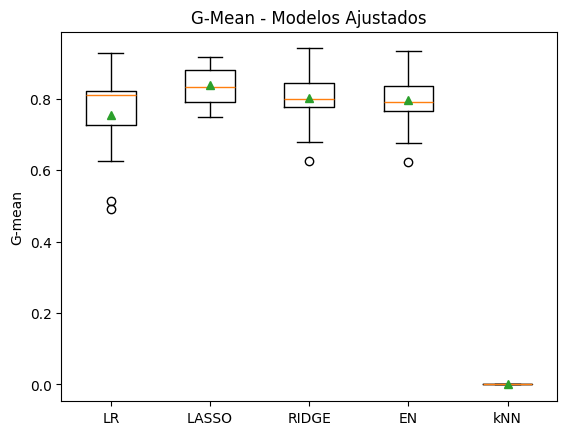

In [45]:
# 5)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# NOTA: puedes agregar todas las celdas que consideres adecuado.

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
import matplotlib.pyplot as plt
import numpy as np

def mis_modelos_ajustados():
    modelos, nombres = list(), list()

    modelos.append(
        LogisticRegression(
            penalty=None,
            class_weight='balanced',
            max_iter=3000,
            random_state=1
        )
    )
    nombres.append('LR')

    modelos.append(
        LogisticRegression(
            penalty='l1',
            solver='liblinear',
            class_weight='balanced',
            C=0.1,
            max_iter=3000,
            random_state=1
        )
    )
    nombres.append('LASSO')

    modelos.append(
        LogisticRegression(
            penalty='l2',
            class_weight='balanced',
            C=1.0,
            max_iter=3000,
            random_state=1
        )
    )
    nombres.append('RIDGE')

    modelos.append(
        LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=0.5,
            class_weight='balanced',
            C=0.5,
            max_iter=5000,
            random_state=1
        )
    )
    nombres.append('EN')

    modelos.append(
        KNeighborsClassifier(
            n_neighbors=15,
            weights='distance'
        )
    )
    nombres.append('kNN')

    return modelos, nombres


# Ejecución y evaluación

modelos, nombres = mis_modelos_ajustados()
resultados = list()

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)

print('Resultados de Validación (G-mean):\n')

for i in range(len(modelos)):
    pipeline = Pipeline(steps=[('ct', columnasTransformer),
                               ('m', modelos[i])])

    scores = cross_validate(
        pipeline,
        Xtv,
        np.ravel(ytv),
        scoring={'m_geo': mi_metrica},
        cv=cv,
        n_jobs=-1
    )

    resultados.append(scores['test_m_geo'])

    print(nombres[i])
    print('G-mean: >> %.3f (%.3f)\n' %
          (np.nanmean(scores['test_m_geo']),
           np.nanstd(scores['test_m_geo'])))

# Boxplot

plt.boxplot(resultados, tick_labels=nombres, showmeans=True)
plt.title("G-Mean - Modelos Ajustados")
plt.ylabel("G-mean")
plt.show()


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# **Ejercicio-6**

### **a) Selecciona el que consideres sea el mejor modelo encontrado, busca la mejor configuración de hiperparámetros y utilízalo para encontrar su matriz de confusión. Sigue utilizando los mismos conjuntos de entrenamiento y validación. Llamar "ytrain_hat" y "yval_hat" a las predicciones de los conjuntos de entrenamiento y validación, respectivamente, obtenidas con el mejor modelo. Verifica que no ahora no quede sobreentrenado.**

###  **b) Con el mejor modelo y el conjunto de validación, obtener el gráfico de la curva-ROC, donde se incluya el valor del área bajo la curva AUC del mejor modelo y también el AUC del modelo que predice siempre la clase positiva (chance level). Ver documentación. ¿Qué nos dice esta gráfica?**

###  **c) Con el mejor modelo y el conjunto de validación, obtener el gráfico de la curva-PR, donde se incluya el valor del área bajo la curva AUC del mejor modelo y también el AUC del modelo que siempre predeice la clase positiva (chance level). Ver documentación. ¿Qué nos dice esta gráfica?**




In [46]:
# 6a)

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**

# NOTA: puedes agregar todas las celdas que consideres adecuado.


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from imblearn.metrics import geometric_mean_score

# Definimos el mejor modelo (LASSO ajustado)
mejor_modelo = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    C=0.1,
    max_iter=3000,
    random_state=1
)

# Pipeline
pipeline_best = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('m', mejor_modelo)
])

# Entrenamos con Train
pipeline_best.fit(Xtrain, np.ravel(ytrain))

# Predicciones
ytrain_hat = pipeline_best.predict(Xtrain)
yval_hat = pipeline_best.predict(Xval)



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

print('G-mean del mejor modelo-Train: %.4f' % geometric_mean_score(np.ravel(ytrain), ytrain_hat))
print('G-mean del mejor modelo-Val: %.4f' % geometric_mean_score(np.ravel(yval), yval_hat))

print("\nMatriz de Confusión con Validación:\n", confusion_matrix(np.ravel(yval), yval_hat))

G-mean del mejor modelo-Train: 0.8611
G-mean del mejor modelo-Val: 0.9341

Matriz de Confusión con Validación:
 [[137  20]
 [  0   8]]


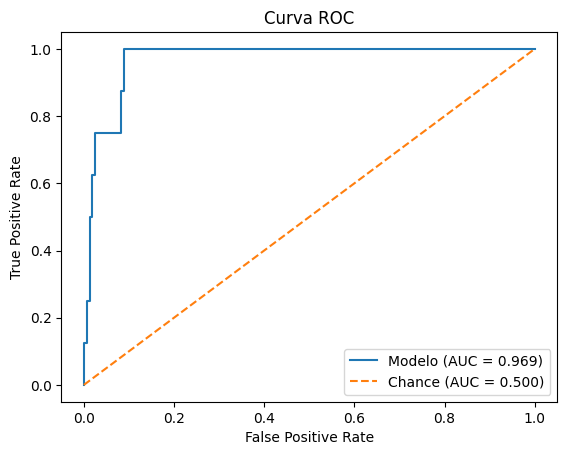

In [47]:
# 6b)

# **+++++++++++ Inicia sección para agregar código ++++++++++++++**


from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Probabilidades para la clase positiva
yval_proba = pipeline_best.predict_proba(Xval)[:, 1]

# ROC del mejor modelo
fpr, tpr, _ = roc_curve(yval, yval_proba)
auc_modelo = roc_auc_score(yval, yval_proba)

# ROC del modelo aleatorio (chance level)
chance_proba = np.ones(len(yval))
fpr_c, tpr_c, _ = roc_curve(yval, chance_proba)
auc_chance = roc_auc_score(yval, chance_proba)

# Gráfica
plt.plot(fpr, tpr, label=f'Modelo (AUC = {auc_modelo:.3f})')
plt.plot(fpr_c, tpr_c, '--', label=f'Chance (AUC = {auc_chance:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++
#### Comentario del gráfico curva ROC:

* 6b) La curva ROC del mejor modelo se encuentra claramente por encima de la línea de referencia (chance level), lo que indica que el modelo tiene una buena capacidad de discriminación entre las clases con y sin derrame. El valor del AUC confirma que el modelo distingue adecuadamente entre ambas clases y no realiza predicciones al azar. Sin embargo, dado el desbalance de clases, esta métrica debe interpretarse con cautela y complementarse con otras métricas.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

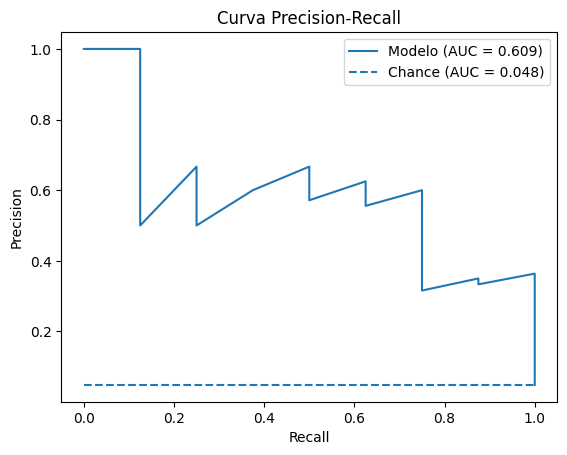

In [48]:
# 6c)
# **+++++++++++ Inicia sección para agregar código ++++++++++++++**


from sklearn.metrics import precision_recall_curve, average_precision_score

# PR del mejor modelo
precision, recall, _ = precision_recall_curve(yval, yval_proba)
auc_pr_modelo = average_precision_score(yval, yval_proba)

# PR del chance level
chance_precision = yval.mean()
auc_pr_chance = chance_precision

# Gráfica
plt.plot(recall, precision, label=f'Modelo (AUC = {auc_pr_modelo:.3f})')
plt.hlines(
    y=chance_precision,
    xmin=0,
    xmax=1,
    linestyles='dashed',
    label=f'Chance (AUC = {auc_pr_chance:.3f})'
)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### +++++++++++ Inicia sección para agregar texto ++++++++++++++++
#### Comentario del gráfico curva PR:

* 6c) La curva Precision–Recall muestra un desempeño superior al nivel de referencia (chance level), lo que indica que el modelo identifica derrames reales con una precisión razonable. Esta gráfica es especialmente relevante en problemas con clases desbalanceadas, ya que refleja de mejor manera el compromiso entre precisión y recall para la clase positiva. El valor del AUC-PR confirma que el modelo es útil para detectar derrames y no está dominado por la clase mayoritaria.


### +++++++++++ Termina sección para agregar texto ++++++++++++++

# **Ejercicio-7**

### **Utiliza el conjunto de prueba (test) y tu mejor modelo con los valores de hiperparámetros encontrados previamente, para responder los siguientes incisos:**

**a) El valor de la media geométrica G_mean.**

**b) La matriz de confusión.**

**c) El reporte de métricas classification_report_imbalanced:**



In [49]:
# 7a)

print('G-mean del mejor modelo con el conjunto de prueba (test):')

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


# Entrenamos el mejor modelo usando Train + Validation
pipeline_best.fit(Xtv, np.ravel(ytv))

# Predicciones en test
ytest_hat = pipeline_best.predict(Xtest)

# G-mean
print(geometric_mean_score(np.ravel(ytest), ytest_hat))




# **+++++++++++ Termina sección para agregar código ++++++++++++++**

G-mean del mejor modelo con el conjunto de prueba (test):
0.9428090415820634


In [50]:
# 7b)

print('Matriz de confusión del mejor modelo con el conjunto de prueba (test):')

# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


from sklearn.metrics import confusion_matrix

print(confusion_matrix(np.ravel(ytest), ytest_hat))



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

Matriz de confusión del mejor modelo con el conjunto de prueba (test):
[[96 12]
 [ 0  5]]


In [51]:
# 7c)

print("Reporte de métricas con el conjunto de prueba (test):\n")


# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


from imblearn.metrics import classification_report_imbalanced

print(classification_report_imbalanced(np.ravel(ytest), ytest_hat))



# **+++++++++++ Termina sección para agregar código ++++++++++++++**

Reporte de métricas con el conjunto de prueba (test):

                   pre       rec       spe        f1       geo       iba       sup

          0       1.00      0.89      1.00      0.94      0.94      0.88       108
          1       0.29      1.00      0.89      0.45      0.94      0.90         5

avg / total       0.97      0.89      1.00      0.92      0.94      0.88       113



# **Ejercicio-8**

### **Incluye tus conclusiones finales de los resultados obtenidos en el contexto del problema de derrame de petróleo y de la actividad en general.**


### +++++++++++ Inicia sección de Conclusiones ++++++++++++++++

En esta actividad se trabajó con un problema de clasificación con clases desbalanceadas enfocado en la detección de derrames de petróleo. A lo largo del análisis se observó que la métrica de exactitud puede ser engañosa, ya que modelos muy simples pueden obtener valores altos sin detectar correctamente los derrames. Por esta razón, el uso de la métrica G-mean resultó más adecuado para evaluar el desempeño real de los modelos.

Al comparar distintos modelos, se encontró que los modelos de regresión logística, en particular el modelo LASSO con pesos balanceados, ofrecieron un mejor desempeño y mayor estabilidad que otras alternativas. Además, las evaluaciones con curvas ROC y Precision–Recall mostraron que el modelo logra distinguir adecuadamente entre las clases y supera claramente el desempeño al azar.

Finalmente, los resultados obtenidos en el conjunto de prueba fueron consistentes con los de validación, lo que indica que el modelo generaliza bien y no presenta sobreentrenamiento. En general, la actividad permitió entender la importancia de elegir métricas adecuadas y de evaluar correctamente los modelos en problemas reales con datos desbalanceados.


### +++++++++++ Termina sección de conclusiones ++++++++++++++

# **<<< Fin de la Actividad de la Semana - curvas ROC y PR : Oil-Spill >>>**